# 01 · Your first dispatch solve

Allocate an 80 MW load between two generators and check the marginal price.

**Time:** about 10 minutes. **Package:** PySPD 0.1.0. **Platform tested:** macOS ARM64, Python 3.13.

Run the cells from top to bottom in a fresh kernel. This notebook contains all
its model-building code and uses only the installed package. All data are
fictional; no GDX file, GAMS runtime, repository checkout, or earlier notebook
is needed. Install `pyspd==0.1.0`, `jupyterlab`, `matplotlib`, and `pandas` in
your environment before opening it. SCIP and HiGHS arrive with PySPD.

In [1]:
import math
import sys
from importlib.metadata import version

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

assert sys.version_info[:2] == (3, 13), "Select a Python 3.13 notebook kernel"
assert version("pyspd") == "0.1.0", "These examples target pyspd==0.1.0"
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.2,
        "figure.dpi": 110,
    }
)
pd.options.display.float_format = "{:,.3f}".format
print({name: version(name) for name in ("pyspd", "highspy", "pyscipopt")})

{'pyspd': '0.1.0', 'highspy': '1.15.1', 'pyscipopt': '5.7.1'}


In [2]:
from pyspd.architecture import ModelAssembler
from pyspd.core_energy import (
    CoreEnergyCase,
    CoreEnergyPricingEngine,
    CoreEnergyResultSchema,
    CoreEnergySolvePolicy,
    core_energy_formulation,
)

## Construct a small normalized case

Keys identify `(case, period, offer, block)`. Both offers have a single price
block. One interval lasts one hour. Ramps are nonbinding, and the small
movement tie-break penalty is explicitly set to zero so the arithmetic is
transparent. This is the energy-only LP, solved directly by HiGHS; the reserve
example later demonstrates the full SCIP-to-HiGHS solve policy.

In [3]:
def energy_case(demand=80.0, cheap_capacity=60.0, cheap_price=20.0):
    """One fictional island, two offers, one hour, no losses or ramp limits."""
    period = ("DEMO", "H1")
    region = (*period, "NI")
    offers = frozenset((*period, name) for name in ("CHEAP", "LOCAL"))
    blocks = frozenset((*offer, "1") for offer in offers)
    return CoreEnergyCase(
        case_id="DEMO",
        periods=frozenset({period}),
        regions=frozenset({region}),
        offers=offers,
        offer_blocks=blocks,
        primary_offers=offers,
        offer_region={offer: region for offer in offers},
        required_load={region: demand},
        offer_limit={
            block: cheap_capacity if block[2] == "CHEAP" else 120.0 for block in blocks
        },
        offer_price={
            block: cheap_price if block[2] == "CHEAP" else 70.0 for block in blocks
        },
        generation_start={offer: 0.0 for offer in offers},
        ramp_rate_up={offer: 10000.0 for offer in offers},
        ramp_rate_down={offer: 10000.0 for offer in offers},
        interval_minutes={period: 60.0},
        study_mode={period: 130.0},
        movement_penalty=0.0,
    )

In [4]:
def solve_energy(case):
    built = ModelAssembler().assemble(core_energy_formulation(), case)
    solved = CoreEnergySolvePolicy().solve(built)
    assert solved.solution_loaded, "No optimal solution was loaded"
    results = CoreEnergyResultSchema().collect(built, solved)
    prices = CoreEnergyPricingEngine().price(built, solved)
    generation = {key[2]: value for key, value in results.generation.items()}
    deficit = sum(results.deficit.values())
    surplus = sum(results.surplus.values())
    assert (
        abs(
            sum(generation.values())
            + deficit
            - surplus
            - sum(case.required_load.values())
        )
        < 1e-6
    )
    cost = sum(
        generation[key[2]] * case.offer_price[(*key, "1")] for key in case.offers
    )
    return {
        **generation,
        "demand_mw": sum(case.required_load.values()),
        "cost_nzd_per_hour": cost,
        "price_nzd_per_mwh": next(iter(prices.values.values())),
        "deficit_mw": deficit,
        "surplus_mw": surplus,
    }

## Predict the result

The cheap offer supplies up to 60 MW at NZD 20/MWh. The local offer can supply
120 MW at NZD 70/MWh. At an 80 MW load, expect 60 + 20 MW of generation,
NZD 2,600 for this one-hour interval, and a marginal price of NZD 70/MWh.

In [5]:
case = energy_case(demand=80.0)
result = solve_energy(case)
display(pd.DataFrame([result]))
assert math.isclose(result["CHEAP"], 60.0, abs_tol=1e-6)
assert math.isclose(result["LOCAL"], 20.0, abs_tol=1e-6)
assert math.isclose(result["cost_nzd_per_hour"], 2600.0, abs_tol=1e-6)
assert result["deficit_mw"] < 1e-6 and result["surplus_mw"] < 1e-6

,CHEAP,LOCAL,demand_mw,cost_nzd_per_hour,price_nzd_per_mwh,deficit_mw,surplus_mw
0,60.000,20.000,80.000,"2,600.000",70.000,0.000,0.000


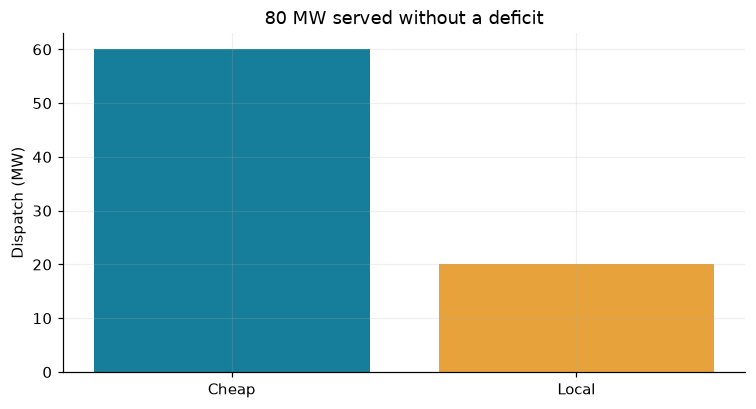

In [6]:
fig, ax = plt.subplots()
ax.bar(
    ["Cheap", "Local"], [result["CHEAP"], result["LOCAL"]], color=["#167d9a", "#e8a23b"]
)
ax.set(ylabel="Dispatch (MW)", title="80 MW served without a deficit")
display(fig)
plt.close(fig)

## Check the price with an extra 0.1 MW

Away from an offer breakpoint, the change in hourly cost divided by the change
in MW should match the marginal price. This check also makes the price sign
convention visible: PySPD maximizes net benefit, while this table reports positive
generation cost.

In [7]:
epsilon = 0.1
perturbed = solve_energy(energy_case(demand=80.0 + epsilon))
finite_difference = (
    perturbed["cost_nzd_per_hour"] - result["cost_nzd_per_hour"]
) / epsilon
assert math.isclose(finite_difference, result["price_nzd_per_mwh"], abs_tol=1e-5)
display(
    pd.Series(
        {
            "reported_price": result["price_nzd_per_mwh"],
            "finite_difference": finite_difference,
        }
    )
)

reported_price      70.000
finite_difference   70.000
dtype: float64

## Try it

Change demand to 40 MW and rerun from the case cell. Both the dispatch mix and
price should change. Update the analytical assertions to reflect your new case.
Avoid testing a unique marginal price exactly at 60 MW: left and right cost
sensitivities differ at that breakpoint.

Continue with **02 · Dispatch, flows, and prices**.